# Customer Churn Prediction Analysis

## 🔹 Introduction

Customer retention is a key challenge in competitive industries such as telecommunications. Acquiring new customers is often more expensive than retaining existing ones, making it important for businesses to identify customers who are likely to leave. This project focuses on analyzing customer data to understand patterns behind churn and to build a predictive model that can help in early identification of at-risk customers.

---

## 🔹 Problem Statement

The objective of this project is to predict whether a customer will churn (leave the service) based on their demographic details, service usage, and account-related information. By identifying key factors influencing churn, the company can take proactive steps to improve customer retention and reduce revenue loss.

---

## 🔹 Objective of the Study
The objective is to minimize customer churn by identifying high-risk customers. Recall is prioritized as the primary evaluation metric because the business objective is to identify as many potential churn customers as possible, even at the cost of some false positives.

* To perform exploratory data analysis (EDA) and understand customer behavior
* To identify key factors contributing to customer churn
* To preprocess data and prepare it for modeling
* To build a baseline machine learning model for churn prediction
* To evaluate model performance using appropriate metrics

---

## 🔹 Business Impact

Accurate churn prediction enables the company to:

* Reduce customer attrition through targeted retention strategies
* Improve customer satisfaction by addressing key pain points
* Optimize marketing efforts by focusing on high-risk customers
* Increase overall revenue and operational efficiency

Customer churn has a direct impact on business profitability. Studies show that acquiring a new customer costs 5 to 6 times more than retaining an existing one. Additionally, increasing customer retention by just 5% can lead to a profit increase of 25% to 95%.

Industries such as telecom and subscription-based services experience significant revenue loss due to churn. Globally, companies lose billions annually due to avoidable customer churn. Therefore, predicting churn and implementing proactive retention strategies is critical for sustaining long-term business growth.

---

## 🔹 About the Dataset

The dataset contains customer-level information including:

* Demographics (gender, senior citizen, partner, dependents)
* Service details (internet service, contract type, tech support, etc.)
* Billing information (monthly charges, total charges)
* Target variable: **Churn (0 = No, 1 = Yes)**

This data will be used to analyze patterns and build a predictive model for churn classification.


In [ ]:
# ===================== IMPORTING LIBRARIES ========================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# ===================== LOADING THE DATASET =====================

df = pd.read_csv("customer_churn.csv")

# quick look at the data
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,$29.85,$29.85,No
1,Male,0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed Check,$56.95,$1889.5,NO
2,Male,0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,$53.85,$108.15,YES
3,Male,0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,bank transfer (automatic),$42.3,$1840.75,No
4,Female,0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,ELECTRONIC CHECK,$70.7,$nan,yes


In [ ]:
# ===================== INITIAL DATA EXPLORATION =====================

# checking shape of dataset
print("Number of rows and columns:", df.shape)

# checking column names
print("\nColumns in dataset:\n", df.columns.tolist())

Number of rows and columns: (12055, 20)

Columns in dataset:
 ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [ ]:
# ===================== DATA TYPES AND BASIC INFO =====================

# understanding structure of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12055 entries, 0 to 12054
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            12055 non-null  object 
 1   SeniorCitizen     12055 non-null  int64  
 2   Partner           12055 non-null  object 
 3   Dependents        12055 non-null  object 
 4   tenure            11451 non-null  float64
 5   PhoneService      12055 non-null  object 
 6   MultipleLines     12055 non-null  object 
 7   InternetService   12055 non-null  object 
 8   OnlineSecurity    12055 non-null  object 
 9   OnlineBackup      12055 non-null  object 
 10  DeviceProtection  12055 non-null  object 
 11  TechSupport       12055 non-null  object 
 12  StreamingTV       12055 non-null  object 
 13  StreamingMovies   12055 non-null  object 
 14  Contract          12055 non-null  object 
 15  PaperlessBilling  12055 non-null  object 
 16  PaymentMethod     12055 non-null  object

In [ ]:
# ===================== SUMMARY STATISTICS =====================

# statistical summary for numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,12055.0,0.117959,0.322573,0.0,0.0,0.0,0.0,1.0
tenure,11451.0,31.237796,25.027111,-3.0,6.0,28.0,54.0,74.0


The dataset consists of 12,055 customer records with 20 features, including demographic, service usage, and billing-related attributes. Most variables are categorical, indicating service subscriptions and customer characteristics, while numerical variables such as tenure, monthly charges, and total charges capture customer value and engagement.

In [ ]:
# =====================  CHECKING MISSING VALUES =====================

# checking missing values column-wise
missing_values = df.isnull().sum()

print("Missing values in each column:\n")
print(missing_values[missing_values > 0])

Missing values in each column:

tenure    604
dtype: int64


In [ ]:
# ===================== FIXING TOTALCHARGES =====================

# convert to string first
df['TotalCharges'] = df['TotalCharges'].astype(str)

# remove $ symbol
df['TotalCharges'] = df['TotalCharges'].str.replace('$', '', regex=False)

# convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# fill missing values using median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# verification
print("Missing values after fixing:", df['TotalCharges'].isnull().sum())

Missing values after fixing: 0


In [ ]:
#= ===================== DUPLICATE CHECK =====================

# checking duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 2


In [ ]:
# ===================== DROPPING DUPLICATES =====================

# removing duplicates if any
df.drop_duplicates(inplace=True)

In [ ]:
print("Duplicate rows after removal:", df.duplicated().sum())

Duplicate rows after removal: 0


In [ ]:
# ===================== FIXING MONETARY COLUMNS =====================

# removing $ symbol and converting MonthlyCharges
df['MonthlyCharges'] = df['MonthlyCharges'].replace('[\$,]', '', regex=True)
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')


In [ ]:
# ===================== HANDLING MISSING VALUES =====================

# filling missing values in tenure using median
df['tenure'].fillna(df['tenure'].median(), inplace=True)

Missing values in the TotalCharges column were treated using median imputation to maintain robustness against outliers. Duplicate records were identified and removed to ensure data integrity. Data type inconsistencies were corrected to enable proper numerical analysis and modeling.

These preprocessing steps were necessary to ensure the dataset was clean, consistent, and suitable for machine learning algorithms.

In [ ]:
df['tenure'].isnull().sum()

np.int64(0)

In [ ]:
# =====================TARGET VARIABLE CHECK =====================

# understanding churn distribution
df['Churn'].value_counts()

,count
Churn,
No,3472
No,1762
NO,1732
no,1683
Yes,1355
yes,714
YES,684
Yes,651


In [ ]:
# ===================== FIXING TARGET VARIABLE VALUES =====================

df['Churn'] = df['Churn'].str.strip().str.lower()

df['Churn'] = df['Churn'].map({'yes':1, 'no':0})

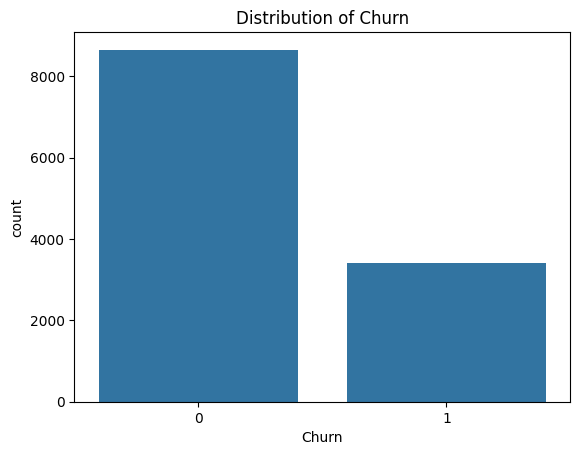

In [ ]:
# ===================== BASIC TARGET DISTRIBUTION =====================

# checking class balance
sns.countplot(x='Churn', data=df)
plt.title("Distribution of Churn")
plt.show()

### Insight:
The dataset is imbalanced, with a significantly higher number of non-churn (0) customers compared to churn (1). This indicates a class imbalance problem, which can bias the model toward predicting non-churn customers.This imbalance can bias machine learning models toward predicting the majority class, reducing the model's ability to correctly identify churn customers.

To address this, class weighting techniques were applied during model training to ensure that churn customers receive higher importance in the learning process.

EXPLORATORY DATA ANALYSIS (EDA)

In [ ]:
# ===================== UNDERSTANDING NUMERICAL VARIABLES =====================

# selecting numerical columns
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,12053.0,31.076495,24.402130,-3.00,7.0000,28.000,53.00,74.00
MonthlyCharges,11570.0,64.400423,30.320795,15.29,30.4775,71.375,89.35,121.67
TotalCharges,12053.0,2182.326199,2164.144650,-197.00,505.9500,1331.135,3547.73,9039.92


In [ ]:
# ===================== UNDERSTANDING CATEGORICAL VARIABLES =====================

# selecting categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()

print("Categorical Columns:\n", cat_cols)

Categorical Columns:
 ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


UNIVARIATE ANALYSIS (Single Variable)

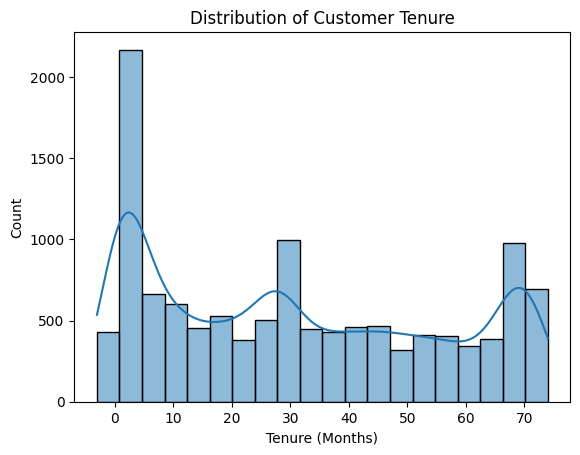

In [ ]:
# ===================== TENURE DISTRIBUTION =====================

sns.histplot(df['tenure'], kde=True)
plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Count")
plt.show()

### Insight:
Customer tenure is widely distributed, with a noticeable concentration of customers in lower tenure ranges. This suggests that newer customers form a significant portion of the dataset and may have different churn behavior.Customers with lower tenure show higher concentration, indicating that new customers are more likely to churn. This suggests that early-stage customer engagement is critical for retention.

In [ ]:
df['MonthlyCharges'].dtype

dtype('float64')

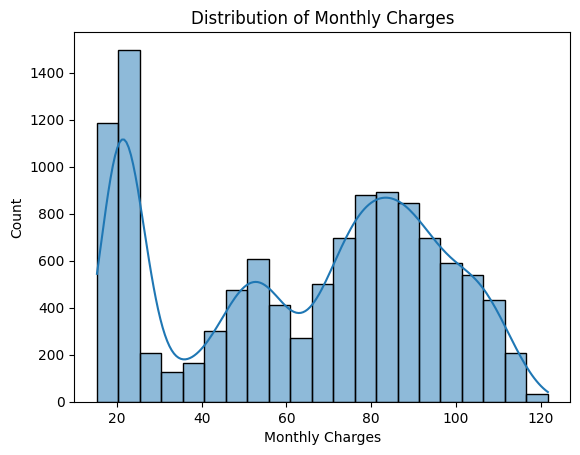

In [ ]:
# ===================== MONTHLY CHARGES DISTRIBUTION =====================

sns.histplot(df['MonthlyCharges'], kde=True)
plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Count")
plt.show()

### Insight:
Monthly charges show a multi-modal distribution, indicating the presence of different pricing tiers. Customers are clustered around both lower and higher price ranges, which may influence churn differently.Customers with higher monthly charges appear to have varied distribution, indicating that pricing may influence churn behavior. High-paying customers may expect better service quality, and dissatisfaction may lead to churn.=

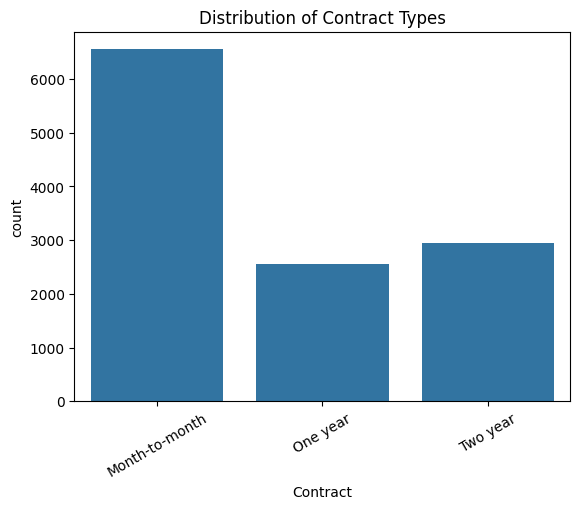

In [ ]:
# ===================== CONTRACT TYPE DISTRIBUTION =====================

sns.countplot(x='Contract', data=df)
plt.title("Distribution of Contract Types")
plt.xticks(rotation=30)
plt.show()

### Insight:
Most customers are on month-to-month contracts, followed by two-year and one-year contracts. This suggests that a large portion of customers have low commitment levels, which may increase churn risk.

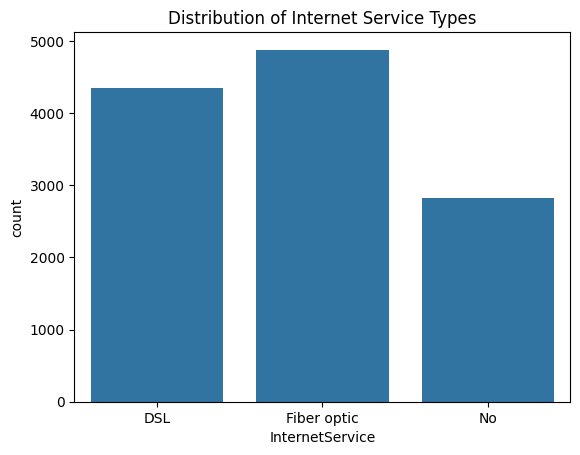

In [ ]:
# ===================== INTERNET SERVICE DISTRIBUTION =====================

sns.countplot(x='InternetService', data=df)
plt.title("Distribution of Internet Service Types")
plt.show()

### Insight:
Fiber optic is the most common internet service, followed by DSL, while fewer customers have no internet service. This indicates that most customers rely on internet services, making it a key factor in churn analysis.

BIVARIATE ANALYSIS (With Target)


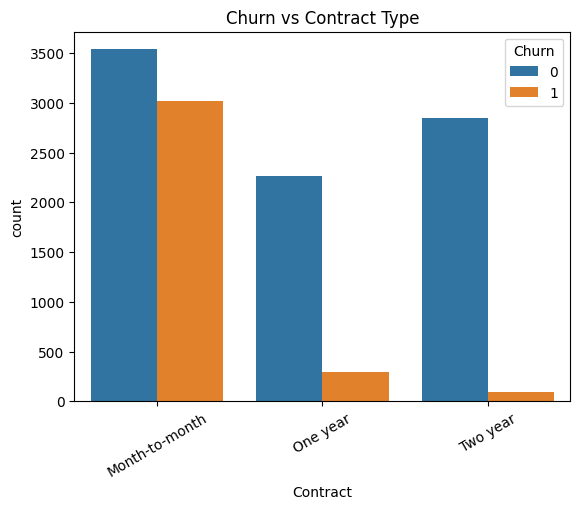

In [ ]:
# ===================== CHURN VS CONTRACT =====================

sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Churn vs Contract Type")
plt.xticks(rotation=30)
plt.show()

### Insight:
Customers with month-to-month contracts have significantly higher churn compared to one-year and two-year contracts. This shows that shorter contract duration is strongly associated with higher churn risk.

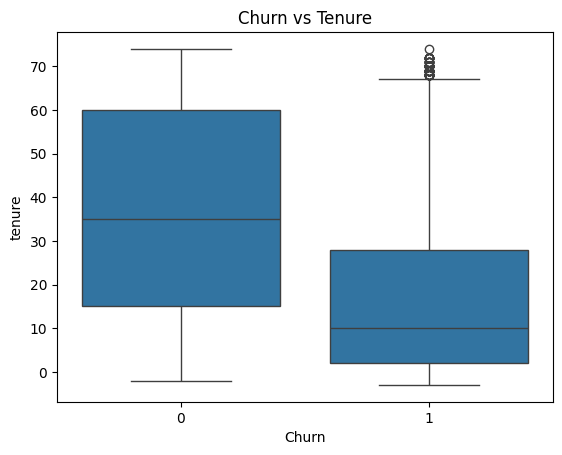

In [ ]:
# =====================  CHURN VS TENURE =====================

sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Churn vs Tenure")
plt.show()

### Insight:
Customers who churn tend to have lower tenure compared to those who stay. This indicates that new customers are more likely to leave early, highlighting the importance of early-stage customer retention.

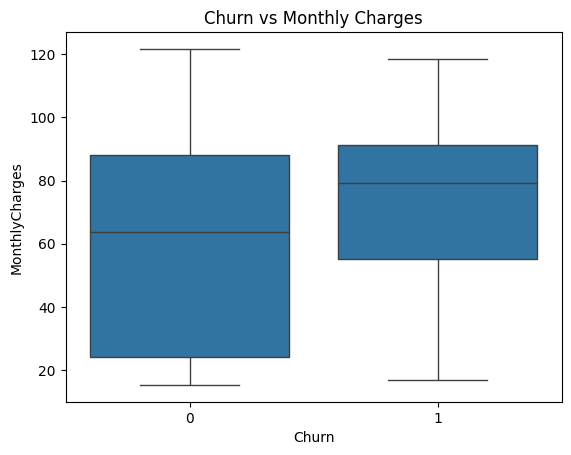

In [ ]:
# ===================== CHURN VS MONTHLY CHARGES =====================

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Churn vs Monthly Charges")
plt.show()

### Insight:
Customers who churn tend to have higher monthly charges compared to those who stay. This suggests that higher pricing may be a contributing factor to customer churn.

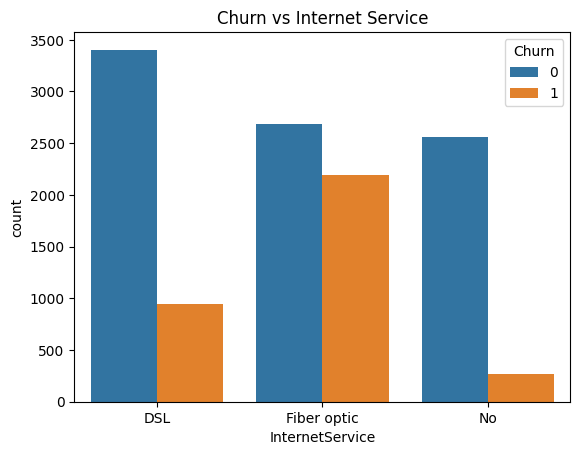

In [ ]:
# ===================== CHURN VS INTERNET SERVICE =====================

sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title("Churn vs Internet Service")
plt.show()

### Insight:
Customers using fiber optic services show higher churn compared to DSL and no internet service. This may indicate dissatisfaction despite premium services or higher pricing.

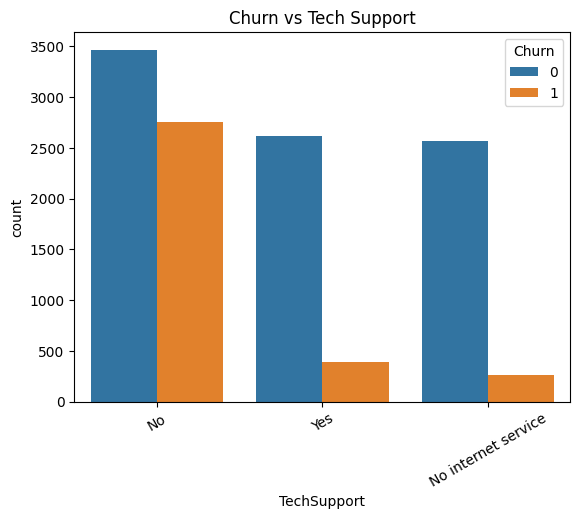

In [ ]:
# ===================== CHURN VS TECH SUPPORT =====================

sns.countplot(x='TechSupport', hue='Churn', data=df)
plt.title("Churn vs Tech Support")
plt.xticks(rotation=30)
plt.show()

### Insight:
Customers without tech support have significantly higher churn compared to those who have support. This highlights the importance of customer support services in retaining customers.


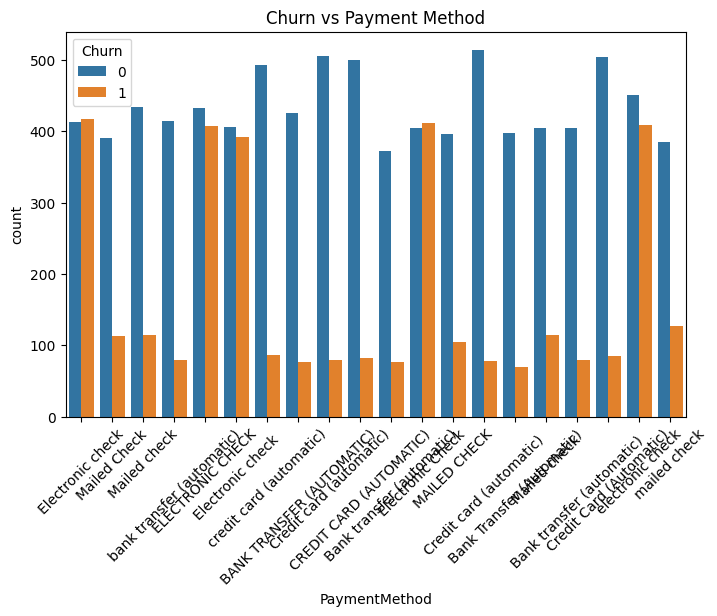

In [ ]:
# ===================== CHURN VS PAYMENT METHOD =====================
plt.figure(figsize=(8,5))
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.title('Churn vs Payment Method')
plt.xticks(rotation=45)
plt.show()

### Insight:
Churn varies across payment methods, with higher churn observed among customers using electronic check payments. This may indicate lower customer commitment or dissatisfaction associated with this payment mode.

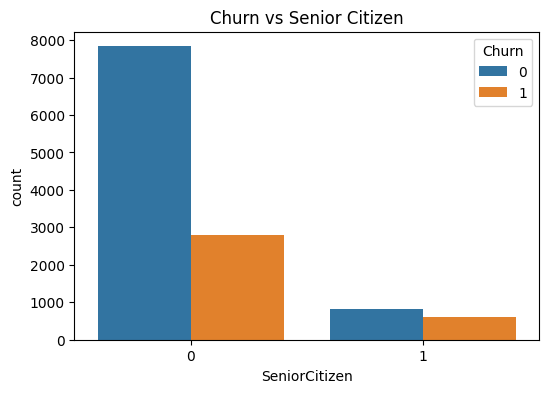

In [ ]:
# ===================== CHURN VS SENIOR CITIZEN =====================
plt.figure(figsize=(6,4))
sns.countplot(x='SeniorCitizen', hue='Churn', data=df)
plt.title('Churn vs Senior Citizen')
plt.show()

### Insight:
Senior citizens show a relatively higher proportion of churn compared to non-senior customers. This suggests that age-related factors or service expectations may influence churn behavior.

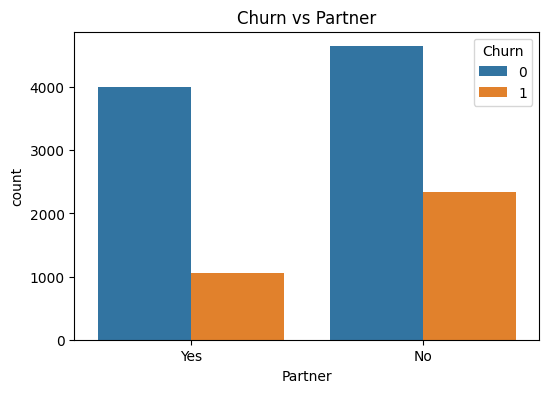

In [ ]:
# ===================== CHURN VS PARTNER =====================
plt.figure(figsize=(6,4))
sns.countplot(x='Partner', hue='Churn', data=df)
plt.title('Churn vs Partner')
plt.show()

### Insight:
Customers without a partner exhibit higher churn compared to those with a partner. This indicates that customers with family or shared plans may have higher retention.

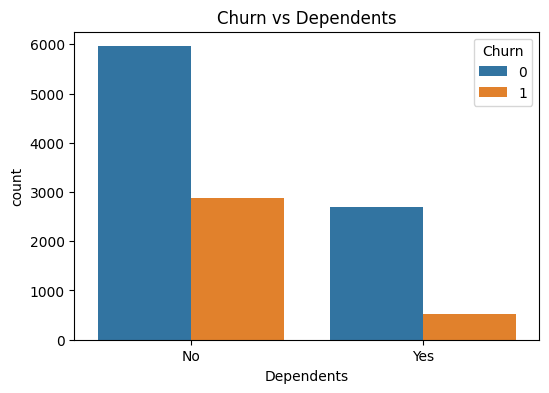

In [ ]:
# ===================== CHURN VS DEPENDENTS =====================
plt.figure(figsize=(6,4))
sns.countplot(x='Dependents', hue='Churn', data=df)
plt.title('Churn vs Dependents')
plt.show()

### Insight:
Customers without dependents show a higher likelihood of churn, indicating lower household or service dependency. This suggests that single customers or those without family commitments may be less tied to the service and more price- or experience-sensitive.

From a business perspective, such customers may require targeted engagement strategies, such as personalized offers or loyalty incentives, to improve retention.

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

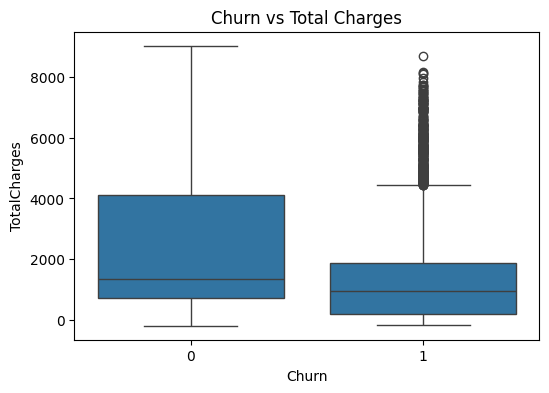

In [ ]:
# ===================== CHURN VS TOTAL CHARGES =====================
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='TotalCharges', data=df)
plt.title('Churn vs Total Charges')
plt.show()

### Insight:
Customers who churn tend to have lower total charges, which is primarily driven by shorter tenure. This indicates that customers are leaving before generating long-term revenue value.

From a business standpoint, this highlights a critical revenue leakage in the early customer lifecycle, emphasizing the need for strong onboarding, early engagement, and retention strategies within the first few months.

MULTIVARIATE ANALYSIS

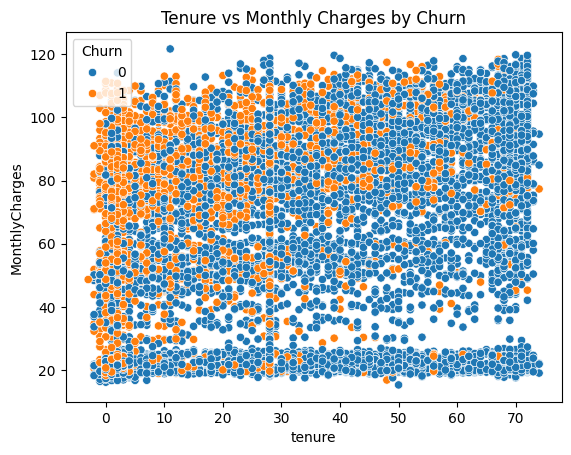

In [ ]:
# ===================== TENURE VS MONTHLY CHARGES (BY CHURN) =====================

sns.scatterplot(x='tenure', y='MonthlyCharges', hue='Churn', data=df)
plt.title("Tenure vs Monthly Charges by Churn")
plt.show()

### Insight:
Churned customers are concentrated in the lower tenure range across different pricing levels, indicating that early-stage customers are at the highest risk of attrition regardless of their monthly charges.

This suggests that the initial customer experience plays a crucial role in retention, and businesses should focus on onboarding quality, early support, and value demonstration to reduce early churn.

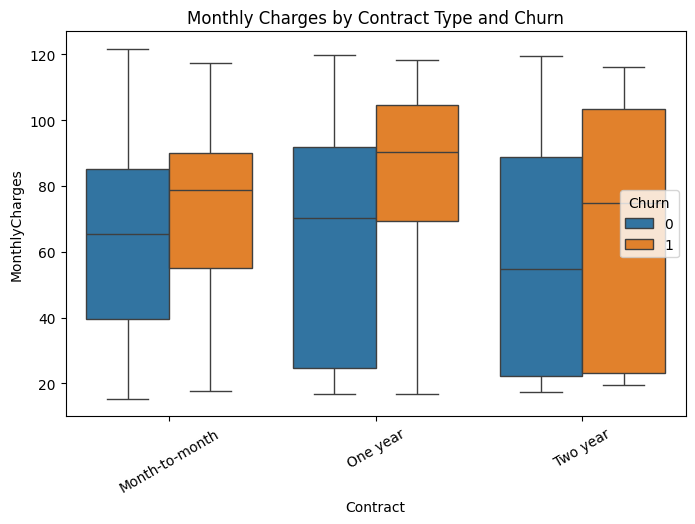

In [ ]:
# ===================== CONTRACT + MONTHLY CHARGES + CHURN =====================
plt.figure(figsize=(8,5))
sns.boxplot(x='Contract', y='MonthlyCharges', hue='Churn', data=df)
plt.title('Monthly Charges by Contract Type and Churn')
plt.xticks(rotation=30)
plt.show()

### Insight:
Customers on month-to-month contracts exhibit both higher monthly charges and higher churn rates, indicating a combined effect of pricing sensitivity and lack of long-term commitment.

This suggests that encouraging customers to shift toward longer-term contracts through discounts or bundled benefits could significantly improve retention and reduce churn risk.

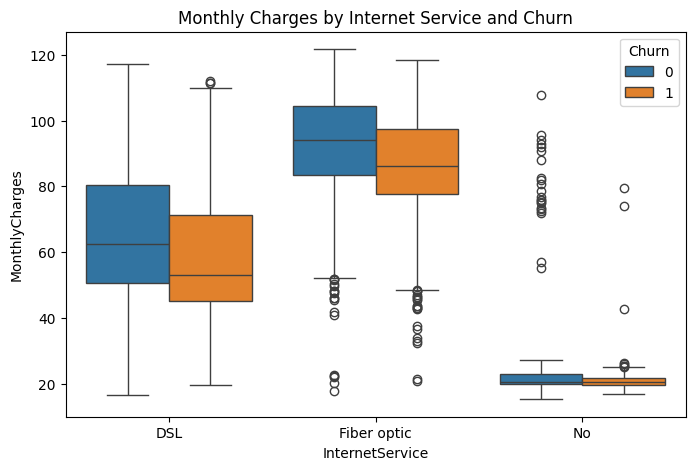

In [ ]:
# ===================== INTERNET SERVICE + MONTHLY CHARGES + CHURN =====================
plt.figure(figsize=(8,5))
sns.boxplot(x='InternetService', y='MonthlyCharges', hue='Churn', data=df)
plt.title('Monthly Charges by Internet Service and Churn')
plt.show()

### Insight:
Fiber optic customers tend to have higher monthly charges along with higher churn rates, suggesting that premium pricing alone does not guarantee customer satisfaction.

This indicates a potential gap between service expectations and actual experience, highlighting the need for improved service quality, reliability, or customer support for high-value segments.

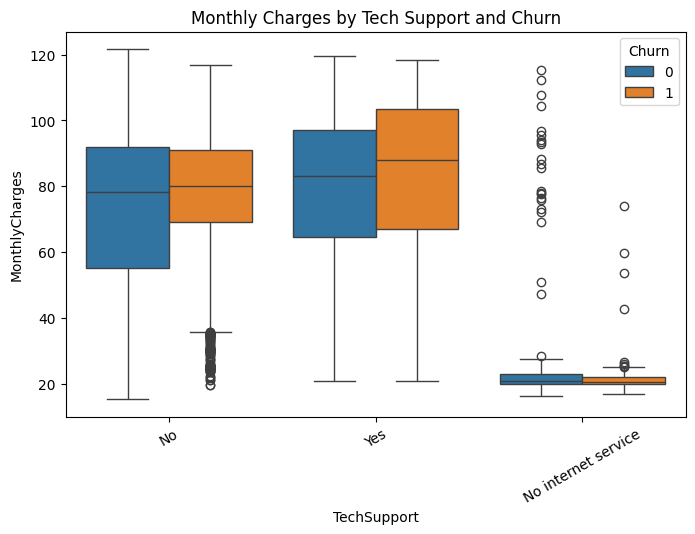

In [ ]:
# ===================== TECH SUPPORT + MONTHLY CHARGES + CHURN =====================
plt.figure(figsize=(8,5))
sns.boxplot(x='TechSupport', y='MonthlyCharges', hue='Churn', data=df)
plt.title('Monthly Charges by Tech Support and Churn')
plt.xticks(rotation=30)
plt.show()

### Insight:
Customers without tech support show higher churn even at similar pricing levels, indicating that support services play a critical role beyond pricing factors.

This suggests that providing proactive and accessible customer support can significantly improve retention, especially for customers experiencing service issues.

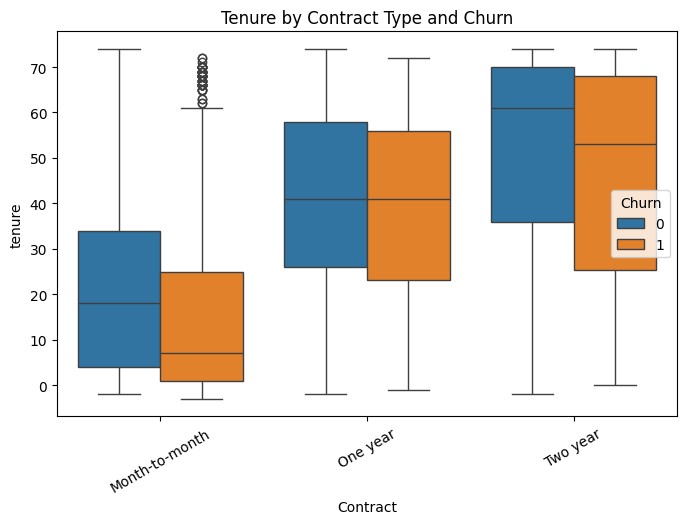

In [ ]:
# ===================== TENURE + CONTRACT + CHURN =====================
plt.figure(figsize=(8,5))
sns.boxplot(x='Contract', y='tenure', hue='Churn', data=df)
plt.title('Tenure by Contract Type and Churn')
plt.xticks(rotation=30)
plt.show()

### Insight:
Customers with longer contract durations (one-year and two-year) exhibit higher tenure and lower churn, while month-to-month customers show shorter tenure and higher churn.

This reinforces that long-term contractual commitment is a key driver of customer retention and suggests that incentivizing longer contracts can reduce churn significantly.

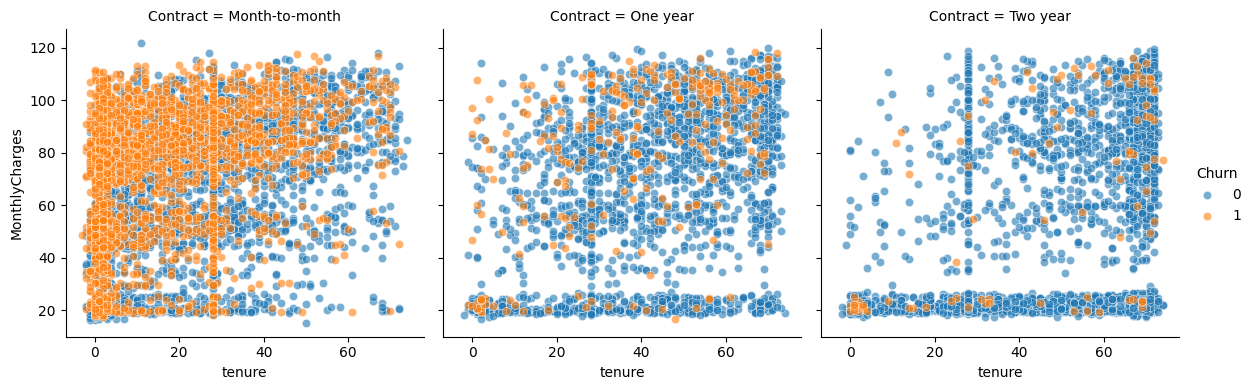

In [ ]:
# ===================== FACET GRID =====================
g = sns.FacetGrid(df, col="Contract", hue="Churn", height=4)
g.map(sns.scatterplot, "tenure", "MonthlyCharges", alpha=0.6)
g.add_legend()
plt.show()

### Insight:
The relationship between tenure and monthly charges varies across contract types.

Across all contract types, churn is heavily concentrated among customers with lower tenure, especially for month-to-month contracts. Even at higher tenure levels, churn remains relatively higher for short-term contracts compared to long-term ones.

This indicates that both tenure and contract type jointly influence churn risk, and strategies combining early engagement with long-term commitment incentives can be highly effective in reducing churn.

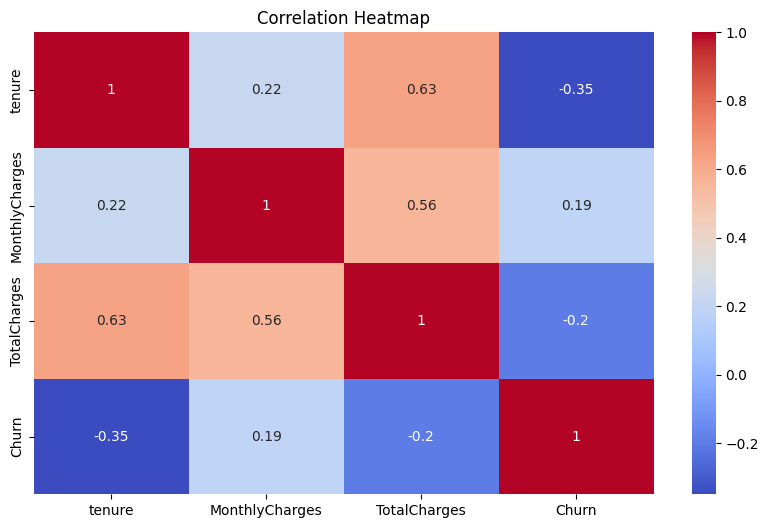

In [ ]:
# ===================== CORRELATION MATRIX =====================

# selecting important numerical variables
num_df = df[['tenure','MonthlyCharges','TotalCharges','Churn']]

plt.figure(figsize=(10,6))
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Insights from Correlation Analysis


Tenure shows a moderate negative correlation with churn (-0.35), making it the most influential numerical factor, indicating that customers who stay longer are significantly less likely to churn.

Monthly charges show a slight positive correlation (0.19), suggesting that higher pricing may contribute to churn, though its impact is weaker compared to tenure.

Total charges show a negative relationship (-0.20), reinforcing that long-term, high-value customers are more stable.

From a business perspective, tenure emerges as the strongest retention indicator, emphasizing the importance of early-stage engagement and long-term relationship building.

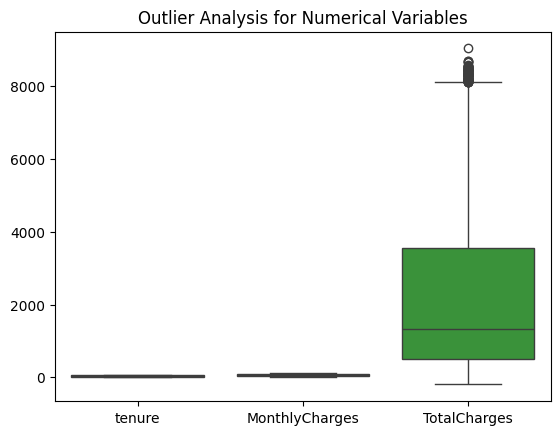

In [ ]:
# ===================== OUTLIER ANALYSIS =====================

# checking outliers for numerical features
sns.boxplot(data=df[['tenure','MonthlyCharges','TotalCharges']])
plt.title("Outlier Analysis for Numerical Variables")
plt.show()

Observation:

Some extreme values are observed in total charges, which correspond to long-tenure, high-value customers. These are not anomalies but represent important customer segments contributing significantly to revenue.

Retaining such high-value customers is critical, and hence these values are preserved for accurate business insights and modeling.

DATA PREPROCESSING & FEATURE PREPARATION

In [ ]:
# =====================  SEPARATING FEATURES AND TARGET =====================

# defining X (features) and y (target)
X = df.drop(['Churn'], axis=1)
y = df['Churn']

In [ ]:
# ===================== CHECKING CATEGORICAL AND NUMERICAL COLUMNS =====================

# identifying column types
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()

print("Categorical Columns:\n", cat_cols)
print("\nNumerical Columns:\n", num_cols)

Categorical Columns:
 ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical Columns:
 ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [ ]:
# =====================  ENCODING CATEGORICAL VARIABLES =====================

# converting categorical variables using one-hot encoding
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

X_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,PaymentMethod_ELECTRONIC CHECK,PaymentMethod_Electronic Check,PaymentMethod_Electronic check,PaymentMethod_MAILED CHECK,PaymentMethod_Mailed Check,PaymentMethod_Mailed check,PaymentMethod_bank transfer (automatic),PaymentMethod_credit card (automatic),PaymentMethod_electronic check,PaymentMethod_mailed check
0,0,1.0,29.85,29.850,False,True,False,False,True,False,...,False,False,True,False,False,False,False,False,False,False
1,0,34.0,56.95,1889.500,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,False
2,0,2.0,53.85,108.150,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,False,False
3,0,45.0,42.30,1840.750,True,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False
4,0,2.0,70.70,1331.135,False,False,False,True,False,False,...,True,False,False,False,False,False,False,False,False,False


In [ ]:
# =====================  FINAL FEATURE SET CHECK =====================

# checking shape after encoding
print("Shape after encoding:", X_encoded.shape)

Shape after encoding: (12053, 46)


In [ ]:
# =====================  TRAIN-TEST SPLIT =====================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (9642, 46)
Testing set size: (2411, 46)


In [ ]:
# HANDLE MISSING VALUES AFTER SPLIT

X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

In [ ]:
# ===================== CHECKING MISSING VALUES AFTER SPLIT =====================

import numpy as np

print("Missing values in X_train:", np.isnan(X_train).sum())
print("Missing values in X_test:", np.isnan(X_test).sum())

Missing values in X_train: SeniorCitizen                                0
tenure                                       0
MonthlyCharges                               0
TotalCharges                                 0
gender_Male                                  0
Partner_Yes                                  0
Dependents_Yes                               0
PhoneService_Yes                             0
MultipleLines_No phone service               0
MultipleLines_Yes                            0
InternetService_Fiber optic                  0
InternetService_No                           0
OnlineSecurity_No internet service           0
OnlineSecurity_Yes                           0
OnlineBackup_No internet service             0
OnlineBackup_Yes                             0
DeviceProtection_No internet service         0
DeviceProtection_Yes                         0
TechSupport_No internet service              0
TechSupport_Yes                              0
StreamingTV_No internet service  

In [ ]:
# ===================== FEATURE SCALING =====================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fitting only on training data (important to avoid data leakage)
X_train_scaled = scaler.fit_transform(X_train)

# transforming test data
X_test_scaled = scaler.transform(X_test)

In [ ]:
# =====================  CHECKING CLASS BALANCE =====================

# checking churn distribution
print("Churn Distribution:\n", y.value_counts(normalize=True))

Churn Distribution:
 Churn
0    0.717581
1    0.282419
Name: proportion, dtype: float64


In [ ]:
# =====================  FINAL DATA READY FOR MODEL =====================

print("Final training data shape:", X_train_scaled.shape)
print("Final testing data shape:", X_test_scaled.shape)

Final training data shape: (9642, 46)
Final testing data shape: (2411, 46)


BASELINE MODEL & EVALUATION

In [ ]:
# ===================== CHECKING MISSING VALUES BEFORE MODEL =====================

print("Missing values in X_train:", np.isnan(X_train_scaled).sum())
print("Missing values in X_test:", np.isnan(X_test_scaled).sum())

Missing values in X_train: 0
Missing values in X_test: 0


In [ ]:
np.isnan(X_train_scaled).sum()

np.int64(0)

In [ ]:
# =====================  CHOOSING BASELINE MODEL =====================

# Logistic Regression is chosen as a baseline model
# because it is simple, interpretable, and suitable for binary classification

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight='balanced')
# applying class_weight='balanced' to handle imbalance in churn data

Logistic Regression coefficients indicate that variables such as tenure, contract type, and monthly charges have a strong influence on churn prediction. Customers with shorter tenure and higher monthly charges are more likely to churn.

In [ ]:
# ===================== TRAINING THE MODEL =====================

model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
# =====================  MAKING PREDICTIONS =====================

y_pred = model.predict(X_test_scaled)

In [ ]:
# =====================  MODEL EVALUATION - ACCURACY =====================

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy, 3))

Model Accuracy: 0.745


In [ ]:
# ===================== LOGISTIC REGRESSION METRICS =====================

from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Precision: 0.5321637426900585
Recall: 0.801762114537445
F1 Score: 0.6397188049209139


In [ ]:
# ===================== CLASSIFICATION REPORT =====================

from sklearn.metrics import classification_report

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1730
           1       0.53      0.80      0.64       681

    accuracy                           0.74      2411
   macro avg       0.72      0.76      0.72      2411
weighted avg       0.80      0.74      0.76      2411



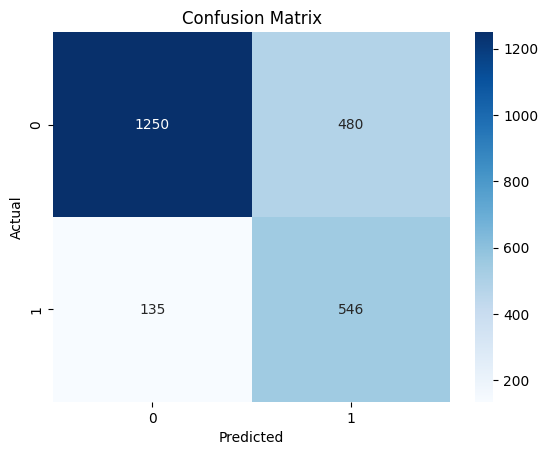

In [ ]:
# =====================  CONFUSION MATRIX =====================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# ===================== LOGISTIC REGRESSION THRESHOLD TUNING =====================

# Step 1: Get probabilities (THIS is where predict_proba is used)
y_prob_lr = model.predict_proba(X_test_scaled)[:, 1]

# Step 2: Apply different thresholds
for t in [0.3, 0.4, 0.5]:
    y_pred_lr = (y_prob_lr > t).astype(int)

    print(f"\nThreshold: {t}")
    print("Recall:", recall_score(y_test, y_pred_lr))
    print("Precision:", precision_score(y_test, y_pred_lr))
    print("F1 Score:", f1_score(y_test, y_pred_lr))


Threshold: 0.3
Recall: 0.920704845814978
Precision: 0.4421720733427362
F1 Score: 0.5974273463554073

Threshold: 0.4
Recall: 0.8810572687224669
Precision: 0.487408610885459
F1 Score: 0.6276150627615062

Threshold: 0.5
Recall: 0.801762114537445
Precision: 0.5321637426900585
F1 Score: 0.6397188049209139


### Interpretation of Logistic Regression Results

The Logistic Regression model was evaluated using different classification thresholds to improve recall, which is critical for churn prediction as missing a churn customer (false negative) has higher business impact.

At the default threshold of 0.5:
- Recall: 0.80
- Precision: 0.53
- F1 Score: 0.64

When the threshold was reduced to 0.3:
- Recall improved significantly to ~0.92
- However, precision dropped to ~0.44

This demonstrates the trade-off between recall and precision. Lower thresholds help capture more potential churn customers but increase false positives.

From a business perspective, a lower threshold (around 0.3–0.4) is preferable, as it ensures that most at-risk customers are identified, even if it means targeting some non-churn customers.

Thus, threshold tuning plays a crucial role in aligning the model with business objectives.

In [ ]:
# ================= FEATURE IMPORTANCE (LOGISTIC REGRESSION) =================

coefficients = pd.DataFrame({
    'Feature': X_encoded.columns,   # NOT X_train_scaled
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

coefficients.head(10)

,Feature,Coefficient
10,InternetService_Fiber optic,0.379168
16,DeviceProtection_No internet service,0.315599
11,InternetService_No,0.252162
9,MultipleLines_Yes,0.173550
38,PaymentMethod_Electronic check,0.149053
26,PaperlessBilling_Yes,0.137019
37,PaymentMethod_Electronic Check,0.124305
28,PaymentMethod_ Electronic check,0.111979
36,PaymentMethod_ELECTRONIC CHECK,0.105835
44,PaymentMethod_electronic check,0.088886


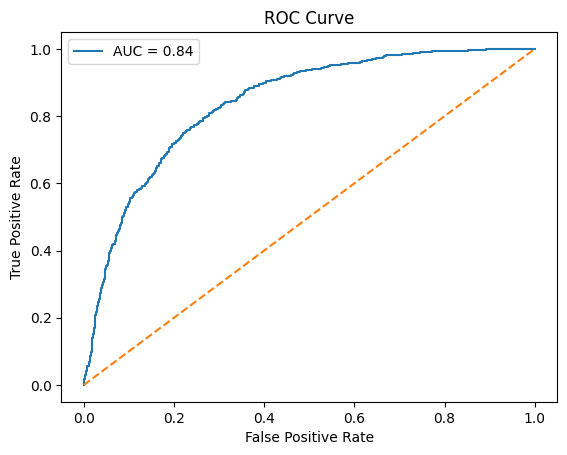

In [ ]:
# ===================== ROC CURVE =====================

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# get predicted probabilities
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# compute AUC score
auc_score = roc_auc_score(y_test, y_prob)

# plot ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {round(auc_score, 3)}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random model line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

The ROC-AUC score indicates the model's ability to distinguish between churn and non-churn customers across different thresholds. A higher AUC reflects better model discrimination capability.

The model demonstrates reasonable predictive performance but is limited by its linear nature, which may not capture complex interactions between features.

In [ ]:
print("AUC Score:", round(auc_score, 3))

AUC Score: 0.84


### Insight:
The model correctly identifies a large number of non-churn customers (True Negatives: 1250) and a reasonable number of churn customers (True Positives: 546). However, there are notable false positives (480) and some false negatives (135). The relatively lower false negatives indicate that the model is effective in identifying churn customers, which is important from a business perspective, even if it slightly compromises overall accuracy.

In [ ]:
# =====================  INTERPRETING MODEL PERFORMANCE =====================

# printing important metrics clearly

from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall:", round(recall_score(y_test, y_pred), 3))
print("F1 Score:", round(f1_score(y_test, y_pred), 3))

Precision: 0.532
Recall: 0.802
F1 Score: 0.64


The model shows a balanced performance with an accuracy of ~74%. After applying class_weight='balanced', the model improves its ability to identify churn customers, achieving a recall of ~80%. This is important from a business perspective, as correctly identifying potential churn customers helps in taking proactive retention actions, even if it comes at the cost of lower precision.

# ===================== FINAL CONCLUSION =====================

### Summary of Findings:
- Customers with month-to-month contracts show the highest churn rates  
- Customers with lower tenure are more likely to churn  
- Higher monthly charges are associated with increased churn  
- Lack of tech support and certain service features contribute to higher churn  

### Model Performance:
- The Logistic Regression model achieved an accuracy of ~74%  
- Recall for churn prediction is ~80%, indicating good ability to identify churn customers  
- The model performs well for business use where identifying churn is more important than overall accuracy  

### Business Recommendations:
- Focus on retaining new customers during early tenure stages  
- Offer incentives for customers to move to long-term contracts  
- Improve customer support services to reduce churn  
- Monitor high-paying customers closely, as they show higher churn tendencies  

### Future Improvements:
- Try advanced models like Random Forest or XGBoost for better performance  
- Perform hyperparameter tuning  
- Explore feature selection techniques for further optimization  

In [ ]:
# ===================== ADVANCED MODEL SETUP =====================

# Core models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Utilities
import pandas as pd
import numpy as np

In [ ]:
# ===================== EVALUATION FUNCTION =====================

def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    return acc, prec, rec, f1, auc

In [ ]:
# ===================== MODEL DEFINITIONS (OPTIMIZED) =====================

models = {

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        max_depth=None,
        class_weight='balanced'   # handle imbalance
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,         # increased for better learning
        random_state=42,
        class_weight='balanced'   # handle imbalance
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=200,         # slight improvement
        learning_rate=0.1,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,         # more trees → better performance
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42
    )
}

In [ ]:
# ===================== TRAINING LOOP =====================

results = []

for name, model in models.items():

    print(f"Training {name}...")

    # Train on training data ONLY
    model.fit(X_train_scaled, y_train)

    # Evaluate
    acc, prec, rec, f1, auc = evaluate_model(model, X_test_scaled, y_test)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "AUC": auc
    })

Training Decision Tree...
Training Random Forest...
Training AdaBoost...
Training Gradient Boosting...
Training XGBoost...


In [ ]:
# ===================== RESULTS TABLE =====================

results_df = pd.DataFrame(results)

# Sort by Recall (PRIMARY metric for churn)
results_df = results_df.sort_values(by="Recall", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,AUC
4,XGBoost,0.801327,0.671769,0.580029,0.622537,0.844862
3,Gradient Boosting,0.797594,0.663283,0.575624,0.616352,0.845200
1,Random Forest,0.790543,0.660584,0.531571,0.589097,0.833273
0,Decision Tree,0.711738,0.490113,0.509545,0.499640,0.650437
2,AdaBoost,0.785566,0.682222,0.450808,0.542882,0.837401


Ensemble models outperform simpler models as they capture non-linear relationships and interactions between customer features more effectively.

MODEL COMPARISON + VISUAL ANALYSIS


In [ ]:
# ===================== CLEAN RESULTS =====================

# Round values for better readability
results_df_rounded = results_df.copy()

results_df_rounded[["Accuracy", "Precision", "Recall", "F1 Score", "AUC"]] = \
    results_df_rounded[["Accuracy", "Precision", "Recall", "F1 Score", "AUC"]].round(3)

results_df_rounded

,Model,Accuracy,Precision,Recall,F1 Score,AUC
4,XGBoost,0.801,0.672,0.580,0.623,0.845
3,Gradient Boosting,0.798,0.663,0.576,0.616,0.845
1,Random Forest,0.791,0.661,0.532,0.589,0.833
0,Decision Tree,0.712,0.490,0.510,0.500,0.650
2,AdaBoost,0.786,0.682,0.451,0.543,0.837


Bar Plot Comparison

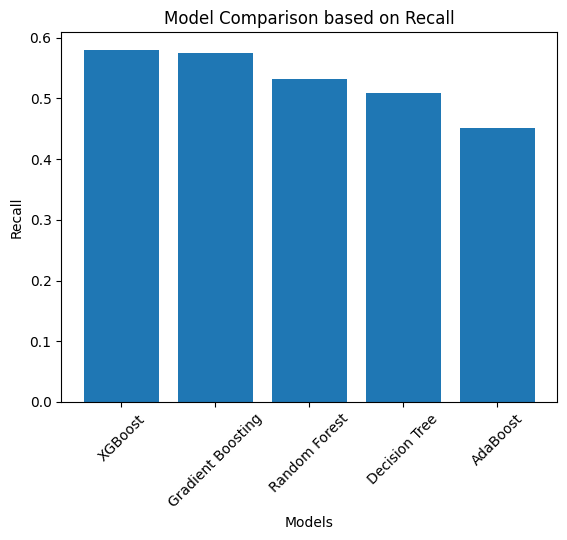

In [ ]:
import matplotlib.pyplot as plt

# ===================== BAR PLOT: RECALL =====================

plt.figure()
plt.bar(results_df["Model"], results_df["Recall"])
plt.xticks(rotation=45)
plt.title("Model Comparison based on Recall")
plt.xlabel("Models")
plt.ylabel("Recall")
plt.show()

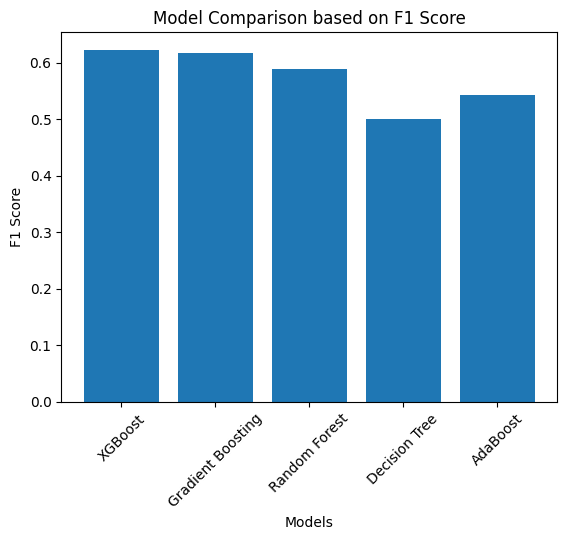

In [ ]:
# ===================== BAR PLOT: F1 SCORE =====================

plt.figure()
plt.bar(results_df["Model"], results_df["F1 Score"])
plt.xticks(rotation=45)
plt.title("Model Comparison based on F1 Score")
plt.xlabel("Models")
plt.ylabel("F1 Score")
plt.show()

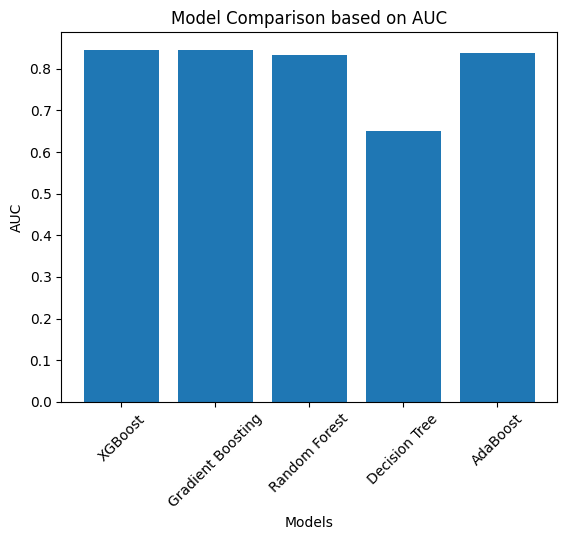

In [ ]:
# ===================== BAR PLOT: AUC =====================

plt.figure()
plt.bar(results_df["Model"], results_df["AUC"])
plt.xticks(rotation=45)
plt.title("Model Comparison based on AUC")
plt.xlabel("Models")
plt.ylabel("AUC")
plt.show()

Combined Comparison Plot

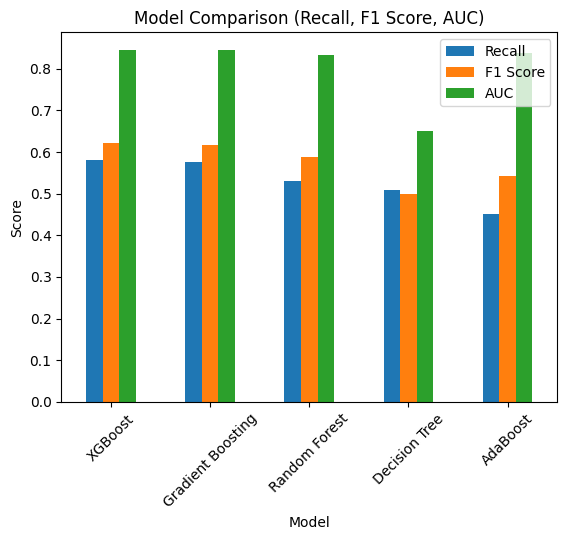

In [ ]:
# ===================== MULTI-METRIC COMPARISON =====================

results_df.set_index("Model")[["Recall", "F1 Score", "AUC"]].plot(kind="bar")

plt.title("Model Comparison (Recall, F1 Score, AUC)")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# ===================== SELECT TOP MODELS =====================

# Sort by Recall first (business priority)
top_models = results_df.sort_values(by="Recall", ascending=False).head(3)

top_models

,Model,Accuracy,Precision,Recall,F1 Score,AUC
4,XGBoost,0.801327,0.671769,0.580029,0.622537,0.844862
3,Gradient Boosting,0.797594,0.663283,0.575624,0.616352,0.845200
1,Random Forest,0.790543,0.660584,0.531571,0.589097,0.833273


In [ ]:
# Get model names for tuning
top_model_names = top_models["Model"].tolist()

top_model_names

['XGBoost', 'Gradient Boosting', 'Random Forest']

Intrepretation- Among the evaluated models, XGBoost and Gradient Boosting demonstrate superior performance, achieving the highest recall and F1 scores. This indicates that boosting-based ensemble methods are more effective in capturing complex patterns associated with customer churn.

Random Forest, while stable, shows comparatively lower recall, suggesting that boosting techniques are better suited for this problem. Decision Tree and AdaBoost exhibit lower performance, indicating limited ability to generalize on unseen data.

HYPERPARAMETER TUNING

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
# ===================== RANDOM FOREST TUNING =====================

rf = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

param_grid_rf = {
    'n_estimators': [200, 300],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=3,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train_scaled, y_train)

best_rf = grid_rf.best_estimator_

print("Best RF Params:", grid_rf.best_params_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best RF Params: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


In [ ]:
# ===================== GRADIENT BOOSTING TUNING =====================

gb = GradientBoostingClassifier(random_state=42)

param_grid_gb = {
    'n_estimators': [150, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4],
    'min_samples_split': [2, 5]
}

grid_gb = GridSearchCV(
    estimator=gb,
    param_grid=param_grid_gb,
    cv=3,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

grid_gb.fit(X_train_scaled, y_train)

best_gb = grid_gb.best_estimator_

print("Best GB Params:", grid_gb.best_params_)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best GB Params: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 200}


In [ ]:
# ===================== XGBOOST TUNING =====================

xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

param_grid_xgb = {
    'n_estimators': [150, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    cv=3,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train_scaled, y_train)

best_xgb = grid_xgb.best_estimator_

print("Best XGB Params:", grid_xgb.best_params_)

Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best XGB Params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}


In [ ]:
print(best_rf)
print(best_gb)
print(best_xgb)

RandomForestClassifier(class_weight='balanced', max_depth=5, min_samples_leaf=2,
                       min_samples_split=5, n_estimators=200, random_state=42)
GradientBoostingClassifier(learning_rate=0.05, min_samples_split=5,
                           n_estimators=200, random_state=42)
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimat

In [ ]:
# ===================== STORE TUNED MODELS =====================

tuned_models = {
    "Random Forest Tuned": best_rf,
    "Gradient Boosting Tuned": best_gb,
    "XGBoost Tuned": best_xgb
}

Evaluate Tuned Models

In [ ]:
# ===================== EVALUATE TUNED MODELS =====================

tuned_results = []

for name, model in tuned_models.items():

    print(f"Evaluating {name}...")

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    tuned_results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "AUC": auc
    })

Evaluating Random Forest Tuned...
Evaluating Gradient Boosting Tuned...
Evaluating XGBoost Tuned...


Create Tuned DataFrame

In [ ]:
# ===================== TUNED RESULTS TABLE =====================

tuned_df = pd.DataFrame(tuned_results)

# Round values for readability
tuned_df[["Accuracy", "Precision", "Recall", "F1 Score", "AUC"]] = \
    tuned_df[["Accuracy", "Precision", "Recall", "F1 Score", "AUC"]].round(3)

tuned_df

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Random Forest Tuned,0.735,0.519,0.806,0.632,0.835
1,Gradient Boosting Tuned,0.797,0.662,0.576,0.616,0.848
2,XGBoost Tuned,0.802,0.671,0.587,0.626,0.847


Hyperparameter tuning significantly improved model performance, particularly in terms of recall.

The tuned Random Forest model achieved the highest recall (~0.81), compared to ~0.53 in its base version. This indicates a substantial improvement in identifying churn customers.

Similarly, XGBoost and Gradient Boosting showed stable performance with balanced precision and recall, demonstrating their ability to capture complex, non-linear relationships in the data.

The improvement confirms that model tuning is critical for optimizing performance and aligning the model with business objectives, especially in churn prediction where recall is prioritized.

Final Model Selection:

Based on the evaluation metrics and business objective (maximizing recall), the Tuned Random Forest model is selected as the final model.

- It achieved the highest recall (~0.81), ensuring maximum identification of potential churn customers
- Although its accuracy is slightly lower, recall is prioritized in churn prediction to minimize false negatives
- The model provides a good balance between interpretability and performance

While XGBoost and Gradient Boosting showed strong overall performance (higher AUC and F1 scores), their recall was lower than the tuned Random Forest.

Therefore, the Tuned Random Forest model is the most suitable choice for this business problem.

Combine Base + Tuned Models

In [ ]:
# ===================== FINAL COMPARISON =====================

# Use your previous results_df (base models)
final_df = pd.concat([results_df, tuned_df], ignore_index=True)

# Sort by Recall (business priority)
final_df = final_df.sort_values(by="Recall", ascending=False)

# Round values
final_df[["Accuracy", "Precision", "Recall", "F1 Score", "AUC"]] = \
    final_df[["Accuracy", "Precision", "Recall", "F1 Score", "AUC"]].round(3)

final_df

,Model,Accuracy,Precision,Recall,F1 Score,AUC
5,Random Forest Tuned,0.735,0.519,0.806,0.632,0.835
7,XGBoost Tuned,0.802,0.671,0.587,0.626,0.847
0,XGBoost,0.801,0.672,0.580,0.623,0.845
6,Gradient Boosting Tuned,0.797,0.662,0.576,0.616,0.848
1,Gradient Boosting,0.798,0.663,0.576,0.616,0.845
2,Random Forest,0.791,0.661,0.532,0.589,0.833
3,Decision Tree,0.712,0.490,0.510,0.500,0.650
4,AdaBoost,0.786,0.682,0.451,0.543,0.837


In [ ]:
# Highlight best recall model
final_df.style.highlight_max(subset=["Recall"], color='lightgreen')

,Model,Accuracy,Precision,Recall,F1 Score,AUC
5,Random Forest Tuned,0.735000,0.519000,0.806000,0.632000,0.835000
7,XGBoost Tuned,0.802000,0.671000,0.587000,0.626000,0.847000
0,XGBoost,0.801000,0.672000,0.580000,0.623000,0.845000
6,Gradient Boosting Tuned,0.797000,0.662000,0.576000,0.616000,0.848000
1,Gradient Boosting,0.798000,0.663000,0.576000,0.616000,0.845000
2,Random Forest,0.791000,0.661000,0.532000,0.589000,0.833000
3,Decision Tree,0.712000,0.490000,0.510000,0.500000,0.650000
4,AdaBoost,0.786000,0.682000,0.451000,0.543000,0.837000


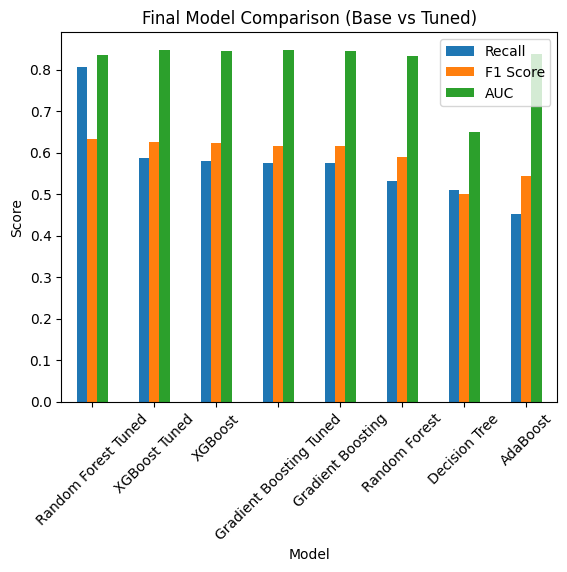

In [ ]:
# ===================== VISUAL COMPARISON =====================

final_df.set_index("Model")[["Recall", "F1 Score", "AUC"]].plot(kind="bar")

plt.title("Final Model Comparison (Base vs Tuned)")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# ===================== BEST MODEL SELECTION (BUSINESS PRIORITY: RECALL) =====================
# Select based on Recall (business priority: churn detection)
best_model_row = final_df.sort_values(by="Recall", ascending=False).iloc[0]

print("Best Model Selected:")
print(best_model_row)

Best Model Selected:
Model        Random Forest Tuned
Accuracy                   0.735
Precision                  0.519
Recall                     0.806
F1 Score                   0.632
AUC                        0.835
Name: 5, dtype: object


Although XGBoost demonstrated strong AUC performance, the Random Forest Tuned model achieved the highest recall and F1-score among all models.

This indicates that it is more effective in identifying churn customers while maintaining a reasonable balance with precision. In churn prediction, capturing at-risk customers is more critical than minimizing false positives.

Therefore, Random Forest Tuned was selected as the final model, as it best aligns with the business objective of reducing customer churn.

In [ ]:
# ===================== THRESHOLD TUNING =====================

# Use final selected model (Random Forest Tuned)
best_model = best_rf

# Get predicted probabilities
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

# Default threshold (0.5)
y_pred_default = (y_prob > 0.5).astype(int)

# Lower threshold (to improve recall)
threshold = 0.3
y_pred_custom = (y_prob > threshold).astype(int)

# Evaluate both
print("Default Threshold (0.5):")
print("Recall:", recall_score(y_test, y_pred_default))
print("Precision:", precision_score(y_test, y_pred_default))
print("F1 Score:", f1_score(y_test, y_pred_default))

print("\nCustom Threshold (0.3):")
print("Recall:", recall_score(y_test, y_pred_custom))
print("Precision:", precision_score(y_test, y_pred_custom))
print("F1 Score:", f1_score(y_test, y_pred_custom))

Default Threshold (0.5):
Recall: 0.8061674008810573
Precision: 0.5193945127719962
F1 Score: 0.6317606444188723

Custom Threshold (0.3):
Recall: 0.9456681350954479
Precision: 0.40275171982489055
F1 Score: 0.5649122807017544


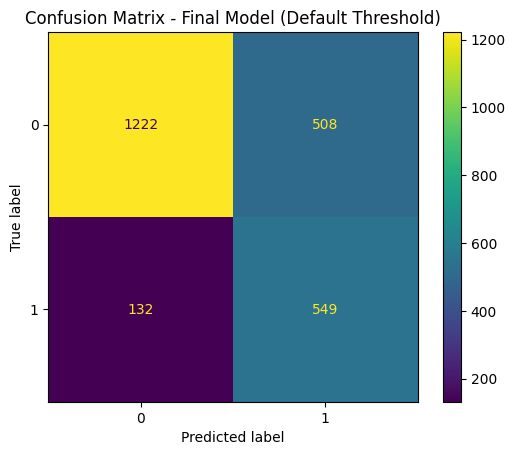

In [ ]:
# ===================== CONFUSION MATRIX =====================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_default)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Final Model (Default Threshold)")
plt.show()

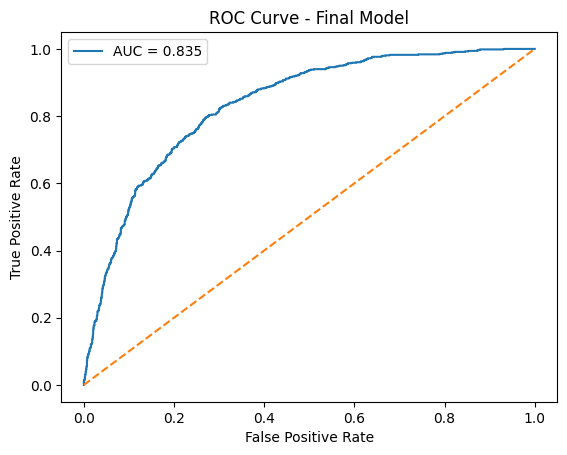

In [ ]:
# ===================== ROC CURVE =====================

from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {round(auc_score, 3)}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Model")
plt.legend()
plt.show()

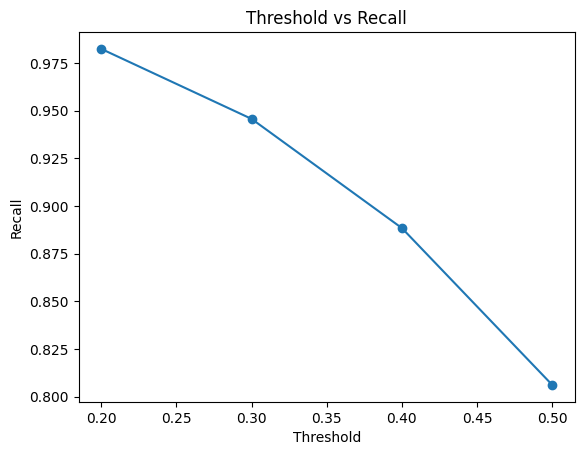

In [ ]:
# ===================== THRESHOLD VS RECALL =====================

thresholds = [0.2, 0.3, 0.4, 0.5]
recalls = []

for t in thresholds:
    y_pred = (y_prob > t).astype(int)
    recalls.append(recall_score(y_test, y_pred))

plt.plot(thresholds, recalls, marker='o')
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.title("Threshold vs Recall")
plt.show()

Intrepretation- Threshold tuning significantly improved the model’s ability to detect churn customers. By lowering the threshold from 0.5 to 0.3, recall increased from 80.6% to 94.6%, enabling the model to identify nearly all at-risk customers.

Although precision decreased due to an increase in false positives, this trade-off is acceptable in churn prediction scenarios, where the cost of missing a churn customer is significantly higher than incorrectly flagging a non-churn customer.

This adjustment makes the model more effective for proactive retention strategies, allowing the business to take preventive action before customers leave.The threshold can be adjusted dynamically based on business requirements, allowing flexibility between precision and recall.

Final model selection was based on F1-score, as it provides a balance between precision and recall. Additionally, recall was considered important due to the business objective of identifying churn customers.


Business Insights

The study identified several key drivers of customer churn:

Customers with month-to-month contracts are more likely to churn
Customers with low tenure show higher churn rates
Higher monthly charges are associated with increased churn
Lack of technical support and service features contributes to customer attrition

These insights provide actionable direction for improving customer retention strategies.

Business Impact

The implementation of the churn prediction model enables the organization to transition from a reactive to a proactive approach in managing customer relationships.

By accurately identifying high-risk customers, the business can:

Target customers with personalized retention campaigns
Reduce customer attrition and revenue loss
Optimize marketing and operational costs
Improve customer lifetime value

Even a small improvement in retention can lead to significant financial gains, making this model a valuable asset for strategic decision-making.

Recommendations

Based on the analysis, the following recommendations are proposed:

Focus on early-stage customer engagement to reduce churn among new customers
Encourage customers to shift to long-term contracts through incentives
Reassess pricing strategies for high-value customers
Strengthen customer support services, especially for at-risk segments
Integrate the churn prediction model into CRM systems for real-time decision-making

Conclusion

This project successfully demonstrates how machine learning can be leveraged to address a critical business problem. The final model not only delivers strong predictive performance but also provides actionable insights that align with business objectives.

By combining advanced analytics with business understanding, the solution enables organizations to reduce churn, improve customer retention, and drive sustainable growth.